In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from numpy import array

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.preprocessing.text import one_hot, Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers  import Activation, Dropout, Dense
from tensorflow.keras.layers import Flatten, GlobalMaxPooling1D, Embedding, LSTM, Conv1D

from sklearn.model_selection import train_test_split

In [2]:
csv_path = r'IMDB_Dataset.csv'
df = pd.read_csv(csv_path)

In [3]:
df.head(1)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive


In [4]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [5]:
TAG_RE = re.compile(r'<[*>]+>')

def remove_tags(text):
  #removes html tags and replaces anything between <> with " "
  return TAG_RE.sub('', text)

In [6]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\David\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
def preprocess_text(sen):
    # Convert to lowercase
    sentence = sen.lower()

    # Remove HTML tags if any
    sentence = remove_tags(sentence)

    # Remove punctuation and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Remove single characters (like 'a', 'b', 'c', etc.) surrounded by spaces
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)

    # Remove multiple spaces with a single space
    sentence = re.sub(r'\s+', ' ', sentence)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    sentence = ' '.join([word for word in sentence.split() if word not in stop_words])

    return sentence

x = []
sentences = list(df['review'])
for sen in sentences:
  x.append(preprocess_text(sen))

In [8]:
y = df['sentiment']
y = np.array(list(map(lambda x: 1 if x=='positive' else 0, y)))

In [9]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['review'])

# Convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(df['review'])

In [10]:
# Compute the maximum length of sequences for reference (optional)
max_word_count = max(len(seq) for seq in sequences)
max_word_count

2493

In [11]:
# Define your maximum length
maxlen = 100

# Pad sequences to the fixed length
sequences_padded = pad_sequences(sequences, padding='post', maxlen=maxlen)

# Assuming you want to split your data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(sequences_padded, y, test_size=0.2, random_state=42)

In [12]:
#Load GloVe word embedding and creade an Embeddings Dictionary

from numpy import asarray
from numpy import zeros

embeddings_dict = dict()
glove_file = open(r'glove.6B.100d.txt', encoding = 'utf8')

for line in glove_file:
  records = line.split()
  word = records[0]
  vector_dimensions = asarray(records[1:], dtype = 'float32')
  embeddings_dict [word] = vector_dimensions
glove_file.close()

In [13]:
# Adding 1 to store dimensions for words for which no pretrained word embeddings exist

vocab_length = len(tokenizer.word_index) + 1

vocab_length

124253

In [14]:
embedding_matrix = zeros([vocab_length, 100])

In [15]:
for word, index in tokenizer.word_index.items():
  embedding_vector = embeddings_dict.get(word)
  if embedding_vector is not None:
    embedding_matrix[index] = embedding_vector

In [16]:
embedding_matrix.shape

(124253, 100)

In [17]:
from tensorflow.keras.layers import LSTM

In [18]:
lstm_model = Sequential()
embedding_layer = Embedding(vocab_length, 100, weights = [embedding_matrix], input_length = maxlen, trainable = False)

lstm_model.add(embedding_layer)
lstm_model.add(LSTM(128))

lstm_model.add(Dense(1, activation = 'sigmoid'))

In [19]:
lstm_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['acc']
)
print(lstm_model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 100)          12425300  
                                                                 
 lstm (LSTM)                 (None, 128)               117248    
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 12,542,677
Trainable params: 117,377
Non-trainable params: 12,425,300
_________________________________________________________________
None


In [20]:
lstm_model_history = lstm_model.fit(X_train, y_train, batch_size = 128, epochs = 6, verbose = 1, validation_split = 0.2)

Epoch 1/6
250/250 [==============================] - 155s 581ms/step - loss: 0.5739 - acc: 0.6940 - val_loss: 0.5199 - val_acc: 0.7499
Epoch 2/6
250/250 [==============================] - 138s 549ms/step - loss: 0.4622 - acc: 0.7807 - val_loss: 0.4200 - val_acc: 0.8024
Epoch 3/6
250/250 [==============================] - 106s 422ms/step - loss: 0.4092 - acc: 0.8121 - val_loss: 0.4242 - val_acc: 0.8115
Epoch 4/6
250/250 [==============================] - 93s 372ms/step - loss: 0.3732 - acc: 0.8327 - val_loss: 0.3669 - val_acc: 0.8311
Epoch 5/6
250/250 [==============================] - 97s 389ms/step - loss: 0.3447 - acc: 0.8498 - val_loss: 0.3504 - val_acc: 0.8460
Epoch 6/6
250/250 [==============================] - 103s 412ms/step - loss: 0.3210 - acc: 0.8623 - val_loss: 0.3597 - val_acc: 0.8446


In [21]:
score = lstm_model.evaluate(X_test, y_test, verbose = 1)
score

313/313 [==============================] - 17s 53ms/step - loss: 0.3585 - acc: 0.8427


[0.35851192474365234, 0.8427000045776367]

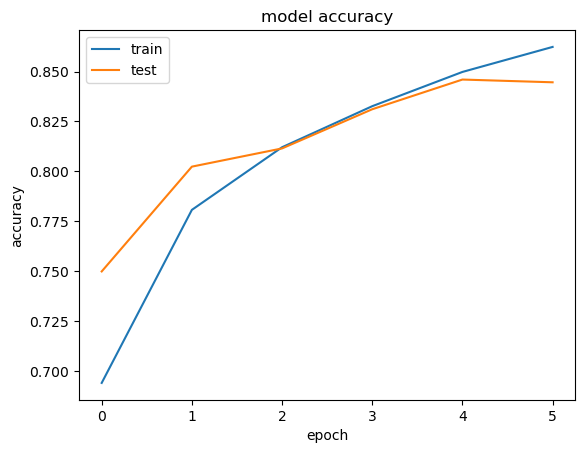

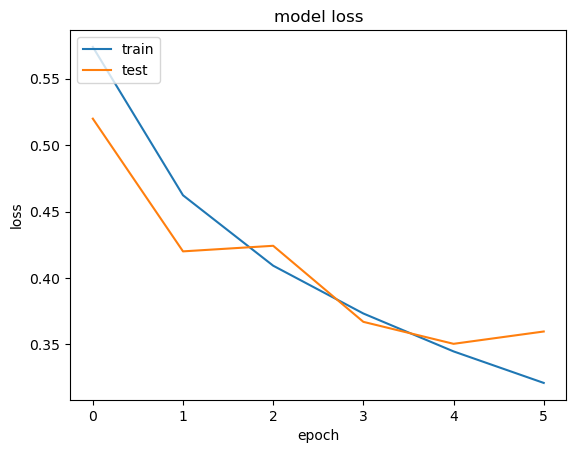

In [22]:
plt.plot(lstm_model_history.history['acc'])
plt.plot(lstm_model_history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(lstm_model_history.history['loss'])
plt.plot(lstm_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [23]:
lstm_model.save(r"C:\Users\David\Documents\ProfitPilot\V6\tests\TEST_1\models\model-1\model-1.h5", save_format='h5')